In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def plot_pm_ra_dec(fits_file, cluster_name, mode="membership"):
    data = fits.open(fits_file)[1].data

    # Get proper motions
    pmRA  = data["GAIAEDR3_PMRA"]
    pmDec = data["GAIAEDR3_PMDEC"]

    pmRA_err  = data["GAIAEDR3_PMRA_ERROR"]
    pmDec_err = data["GAIAEDR3_PMDEC_ERROR"]

    plt.figure(figsize=(6,6))

    if mode == "membership":
        MEM = data["MEMBOOL"]
        members = (MEM == 1) | (MEM == True)
        nonmembers = ~members

        # Background
        plt.scatter(pmRA[nonmembers], pmDec[nonmembers],
                    s=4, alpha=0.2, label="Non-members")
        # Cluster members
        plt.scatter(pmRA[members], pmDec[members],
                    s=8, alpha=0.8, label="Members")

    elif mode == "hdbscan_cluster":
        HDB = data["HDBscan_Cluster"]
        HDBTwo = HDB == -2  
        HDBOne  = HDB == -1  

        # Noise first
        plt.scatter(pmRA[HDBOne], pmDec[HDBOne],
                    s=4, alpha=0.2, label="HDBScan_cluster = -1")
        
        # Main cluster with optional error bars
        plt.errorbar(
            pmRA[HDBTwo], pmDec[HDBTwo],
            xerr=pmRA_err[HDBTwo],
            yerr=pmDec_err[HDBTwo],
            fmt='o',
            markersize=4,
            alpha=0.8,
            elinewidth=0.5,
            capsize=0,
            color='red',  # deep green
            label="HDBSCAN_cluster = -2"
        )

    else:
        raise ValueError("mode must be 'membership' or 'hdbscan_cluster'")

    plt.xlabel("Proper Motion RA (mas/yr)")
    plt.ylabel("Proper Motion Dec (mas/yr)")
    plt.title(f"{cluster_name} Proper Motion")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

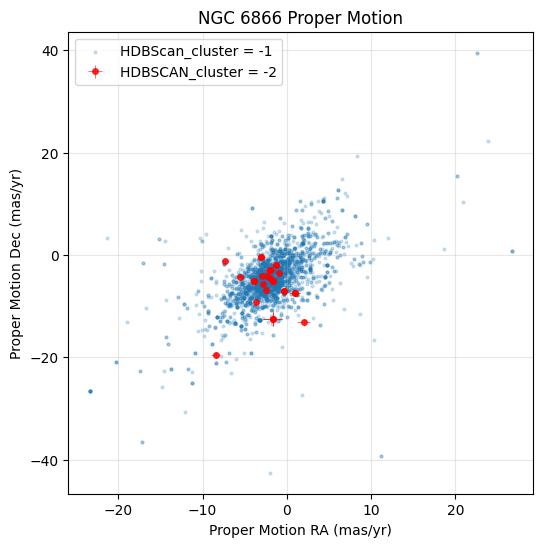

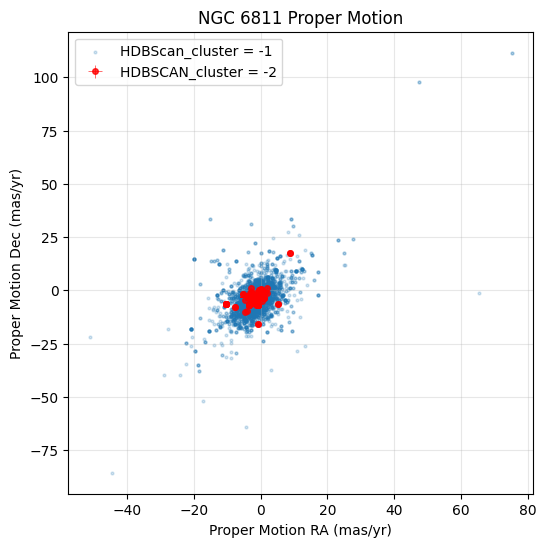

In [14]:
plot_pm_ra_dec("rcat_ngc6866_v0.fits", "NGC 6866", "hdbscan_cluster")
plot_pm_ra_dec("rcat_ngc6811_v0.fits", "NGC 6811", "hdbscan_cluster")